In [1]:
!pip install pandas numpy gdown

In [ ]:
import os
import json
from datetime import datetime
from sklearn.model_selection import train_test_split
import pandas as pd


def make_splits(df, strategy="time+group", seed=42,
                target_col=None,
                group_col=None,
                time_col=None,
                train_size=0.7,
                val_size=0.15,
                test_size=0.15):

    df = df.copy()
    if "row_id" not in df.columns:
        df = df.reset_index().rename(columns={"index": "row_id"})

    splits = {"train": [], "val": [], "test": []}

    if strategy == "time+group":
        df[time_col] = pd.to_datetime(df[time_col])

        df_sorted_list = []
        for _, group in df.groupby(target_col):
            group_sorted = group.sort_values(time_col)
            df_sorted_list.append(group_sorted)

        full_sorted_df = pd.concat(df_sorted_list).reset_index(drop=True)

        for _, group in df.groupby(target_col):
            group_sorted = group.sort_values(time_col)

            n = len(group_sorted)
            train_end = int(n * train_size)
            val_end = train_end + int(n * val_size)

            splits["train"].extend(group_sorted.iloc[:train_end]["row_id"].tolist())
            splits["val"].extend(group_sorted.iloc[train_end:val_end]["row_id"].tolist())
            splits["test"].extend(group_sorted.iloc[val_end:]["row_id"].tolist())

    else:
        raise ValueError("Unknown strategy")

    return splits


def save_splits(splits, out_dir="data/sample", seed=42, strategy="time+group",
                group_col=None, time_col=None):

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs("docs", exist_ok=True)

    for split_name, ids in splits.items():
        path = os.path.join(out_dir, f"splits_{split_name}_ids.txt")

        with open(path, "w", encoding="utf-8") as f:
            for i in ids:
                f.write(str(i) + "\n")

    manifest = {
        "strategy": strategy,
        "seed": seed,
        "generated_at": datetime.utcnow().isoformat(),
        "sizes": {
            "train": len(splits["train"]),
            "val": len(splits["val"]),
            "test": len(splits["test"])
        },
        "columns_used": {
            "group_column": group_col,
            "time_column": time_col
        }
    }

    with open("docs/splits_manifest_lab5.json", "w", encoding="utf-8") as f:
        json.dump(manifest, f, indent=2, ensure_ascii=False)

In [ ]:
import gdown

file_id = "1KiUimW2IcryqFjqWeEbXMmbDZf-_QqfH"
url = f"https://drive.google.com/uc?id={file_id}"

output = "processed_v2.csv"
gdown.download(url, output, quiet=False)

df = pd.read_csv(output)
df = df.dropna(subset=["category_id"])
df = df.dropna(subset=["datePublished"])


Downloading...
From: https://drive.google.com/uc?id=1KiUimW2IcryqFjqWeEbXMmbDZf-_QqfH
To: /content/processed_v2.csv
100%|██████████| 4.43M/4.43M [00:00<00:00, 22.7MB/s]


In [67]:
splits = make_splits(
    df,
    strategy="time+group",
    target_col="category_id",
    time_col="datePublished",
    seed=42
)

save_splits(
    splits,
    out_dir="data/sample",
    seed=42,
    strategy="time+group",
    group_col="category_id",
    time_col="datePublished"
)


/tmp/ipykernel_740/2733710523.py:64: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "generated_at": datetime.utcnow().isoformat(),


Counts:


,train,val,test
category_id,,,
0.0,147,31,32
1.0,144,31,32
2.0,144,30,32
3.0,144,30,32


Percent:


,train,val,test
category_id,,,
0.0,25.39,25.41,25.0
1.0,24.87,25.41,25.0
2.0,24.87,24.59,25.0
3.0,24.87,24.59,25.0


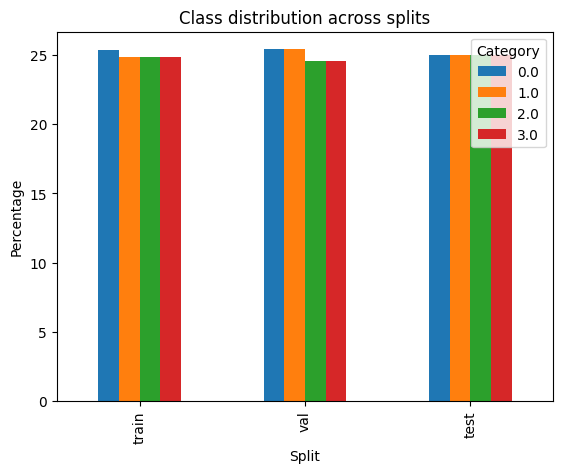

In [73]:
import matplotlib.pyplot as plt

train_df = df.loc[splits["train"]]
val_df = df.loc[splits["val"]]
test_df = df.loc[splits["test"]]

dist_table = pd.DataFrame({
    "train": train_df["category_id"].value_counts(),
    "val": val_df["category_id"].value_counts(),
    "test": test_df["category_id"].value_counts()
}).fillna(0).astype(int)

dist_percent = dist_table.div(dist_table.sum(axis=0), axis=1) * 100

print("Counts:")
display(dist_table)

print("Percent:")
display(dist_percent.round(2))


dist_percent.T.plot(kind="bar")

plt.title("Class distribution across splits")
plt.xlabel("Split")
plt.ylabel("Percentage")
plt.legend(title="Category")
plt.show()

,mean,median,p5,p95
train,1367.01,1258.0,420.60,2645.70
val,1438.00,1296.0,493.85,2771.35
test,1500.50,1359.5,536.40,2941.65


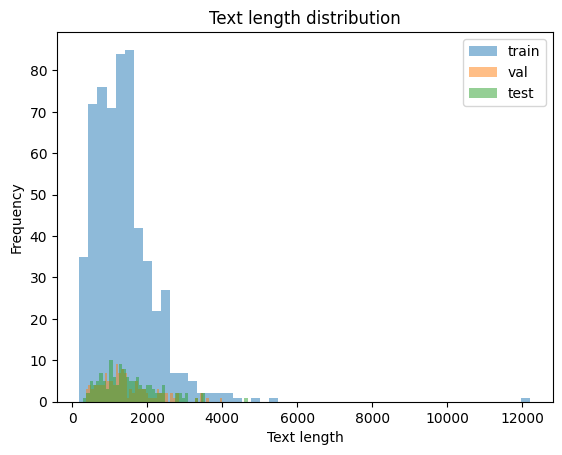

In [ ]:
import ast

train_df["text_length"] = train_df["text"].apply(ast.literal_eval).apply(lambda x: x["clean"]).str.len()
val_df["text_length"] = val_df["text"].apply(ast.literal_eval).apply(lambda x: x["clean"]).str.len()
test_df["text_length"] = test_df["text"].apply(ast.literal_eval).apply(lambda x: x["clean"]).str.len()

def length_stats(data):
    return {
        "mean": data.mean(),
        "median": data.median(),
        "p5": data.quantile(0.05),
        "p95": data.quantile(0.95)
    }

length_table = pd.DataFrame({
    "train": length_stats(train_df["text_length"]),
    "val": length_stats(val_df["text_length"]),
    "test": length_stats(test_df["text_length"])
}).T

display(length_table.round(2))

plt.hist(train_df["text_length"], bins=50, alpha=0.5, label="train")
plt.hist(val_df["text_length"], bins=50, alpha=0.5, label="val")
plt.hist(test_df["text_length"], bins=50, alpha=0.5, label="test")

plt.legend()
plt.title("Text length distribution")
plt.xlabel("Text length")
plt.ylabel("Frequency")
plt.show()

In [68]:
def load_ids(path):
    with open(path) as f:
        return set(int(x.strip()) for x in f)

train_ids = load_ids("data/sample/splits_train_ids.txt")
val_ids = load_ids("data/sample/splits_val_ids.txt")
test_ids = load_ids("data/sample/splits_test_ids.txt")

train_texts = set(df.loc[df.index.isin(train_ids), "text"])
val_texts = set(df.loc[df.index.isin(val_ids), "text"])
test_texts = set(df.loc[df.index.isin(test_ids), "text"])

train_test_dup = len(train_texts & test_texts)
train_val_dup = len(train_texts & val_texts)
val_test_dup = len(val_texts & test_texts)

print("# exact duplicates train∩test =", train_test_dup)
print("# exact duplicates train∩val =", train_val_dup)
print("# exact duplicates val∩test =", val_test_dup)

# exact duplicates train∩test = 0
# exact duplicates train∩val = 0
# exact duplicates val∩test = 0


In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ast

def load_ids(path):
    with open(path) as f:
        return [int(x.strip()) for x in f]

train_ids = load_ids("data/sample/splits_train_ids.txt")
val_ids = load_ids("data/sample/splits_val_ids.txt")
test_ids = load_ids("data/sample/splits_test_ids.txt")

train_df = df.loc[train_ids]
val_df = df.loc[val_ids]
test_df = df.loc[test_ids]

train_texts = train_df["text"].apply(ast.literal_eval).apply(lambda x: x["clean"])
test_texts = test_df["text"].apply(ast.literal_eval).apply(lambda x: x["clean"])

vectorizer = TfidfVectorizer(max_features=20000)

tfidf_train = vectorizer.fit_transform(train_texts)
tfidf_test = vectorizer.transform(test_texts)

sim_matrix = cosine_similarity(tfidf_train, tfidf_test)

threshold = 0.95

pairs = []

for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        if sim_matrix[i, j] >= threshold:
            pairs.append((
                train_df.index[i],
                test_df.index[j],
                sim_matrix[i, j]
            ))

print("Suspicious pairs train vs test:", len(pairs))

for p in pairs[:5]:
    train_id, test_id, sim = p

    print("\n---")
    print("train_id:", train_id, "test_id:", test_id, "similarity:", round(sim,3))
    print("train_text:", df.loc[train_id, "text"][:200])
    print("test_text:", df.loc[test_id, "text"][:200])

Suspicious pairs train vs test: 6

---
train_id: 588 test_id: 489 similarity: 0.985
train_text: {'clean': 'Про це свідчать дані на сайті Національного банку України, передає Укрінформ. Офіційні курси валют на понеділок, 9 лютого, становлять: Середній курс в банках, за даними minfin.com.ua, стано
test_text: {'clean': 'Про це свідчать дані на сайті Національного банку України, передає Укрінформ. Офіційні курси валют на вівторок, 10 лютого, становлять: Середній курс в банках, за даними minfin.com.ua, стано

---
train_id: 421 test_id: 603 similarity: 0.952
train_text: {'clean': "Про це свідчать дані на сайті Національного банку України, передає Укрінформ. Офіційні курси валют на п'ятницю, 13 лютого, становитимуть: Як повідомляв Укрінформ, у проєкті державного бюдже
test_text: {'clean': 'Про це свідчать дані на сайті Національного банку України, передає Укрінформ. Офіційні курси валют на понеділок, 9 лютого, становитимуть: Як повідомляв Укрінформ, у проєкті державного бюдже

---
train_id: 5

In [70]:
import re

patterns = [
    r"category\s*[:=]\s*\w+",
    r"label\s*[:=]\s*\w+",
    r"class\s*[:=]\s*\w+",
    r"topic\s*[:=]\s*\w+"
]

pattern = re.compile("|".join(patterns), re.IGNORECASE)

bad_rows = df[df["text"].str.contains(pattern, na=False)]

print("Suspicious rows found:", len(bad_rows))
for i, row in bad_rows.head(10).iterrows():
    print("\n--- id:", i)
    print(row["text"][:300])

Suspicious rows found: 0


In [71]:
pattern_classes = "sports|politics|economy|culture"

class_leak = df[df["text"].str.contains(pattern_classes, case=False, na=False)]

print("Rows containing class names:", len(class_leak))
class_leak[["text"]].head(10)

Rows containing class names: 2


,text
197,{'clean': 'Про це в коментарі Укрінформу повід...
392,"{'clean': 'Як повідомляє Sky Sports, американк..."


In [72]:
def check_leakage_per_category(split_df, split_name):
    return (
        split_df.groupby("category_id")["datePublished"]
        .agg(["min", "max"])
        .rename(columns={"min": f"{split_name}_min", "max": f"{split_name}_max"})
    )

train_stats = check_leakage_per_category(train_df, "train")
val_stats   = check_leakage_per_category(val_df, "val")
test_stats  = check_leakage_per_category(test_df, "test")

category_dates = train_stats.join(val_stats, how="outer").join(test_stats, how="outer")

category_dates["leakage_ok"] = category_dates["train_max"] <= category_dates["test_min"]

category_dates.reset_index()

,category_id,train_min,train_max,val_min,val_max,test_min,test_max,leakage_ok
0,0.0,2026-01-14T14:52:00+02:00,2026-02-05T06:07:00+02:00,2026-02-05T10:47:00+02:00,2026-02-09T17:47:00+02:00,2026-02-10T13:01:00+02:00,2026-02-13T13:47:54+02:00,True
1,1.0,2026-02-02T10:45:00+02:00,2026-02-10T22:11:00+02:00,2026-02-11T00:41:00+02:00,2026-02-12T13:27:00+02:00,2026-02-12T13:39:31+02:00,2026-02-13T13:22:00+02:00,True
2,2.0,2026-02-05T10:36:00+02:00,2026-02-11T14:37:00+02:00,2026-02-11T14:43:37+02:00,2026-02-12T12:21:00+02:00,2026-02-12T12:38:59+02:00,2026-02-13T13:43:00+02:00,True
3,3.0,2026-02-03T11:58:00+02:00,2026-02-10T19:42:00+02:00,2026-02-10T19:50:00+02:00,2026-02-11T20:44:00+02:00,2026-02-11T22:01:00+02:00,2026-02-13T14:00:11+02:00,True


In [ ]:
report = f"""
# Leakage risk report (Lab 5)

## 1. Стратегія split

У цьому корпусі новин використано комбіновану стратегію split: `Group + Time-based`. Спочатку дані групуються за категорією новини (`category_id`), а потім усередині кожної категорії сортуються за часом публікації (`datePublished`) і розділяються на train/val/test (70/15/15). Такий підхід дозволяє зберегти часову послідовність даних у межах кожної категорії та забезпечує навчання моделі на більш ранніх новинах і тестування на новіших. Це допомагає запобігти `temporal leakage`, коли інформація з майбутніх подій випадково потрапляє до тренувального набору. Крім того, розділення даних усередині кожної категорії дозволяє зберегти їхню присутність у всіх сплітах і уникнути ситуації, коли деякі категорії представлені лише в одному наборі даних. Водночас цей підхід не повністю запобігає можливому `source leakage`, якщо новини з одного джерела з подібним стилем присутні в різних сплітах. Тому додатково варто контролювати метадані джерел або авторів.

## 2. Статистика сплітів

Розміри сплітів:
* train: {len(splits["train"])}
* val: {len(splits["val"])}
* test: {len(splits["test"])}

Баланс класів:
{dist_table}

## 3. Leakage checks results

### Exact duplicate leakage
* exact duplicates train∩test: {train_test_dup}
* exact duplicates train∩val: {train_val_dup}
* exact duplicates val∩test: {val_test_dup}

### Near-duplicate leakage
Suspicious pairs train vs test: {len(pairs)}

### Template / metadata leakage
Suspicious rows found: {len(bad_rows)}
Rows containing class names: {len(class_leak)}

### Time leakage
{category_dates}

## 4. Ризики, що залишились
* Виявлено 6 пар "майже дублів" (near-duplicates) між train і test, що може свідчити про схожі новини або передруки з незначними змінами тексту.
* У текстах знайдено 2 випадки згадування назв класів, що потенційно може підказувати правильну категорію моделі.
* Можливий source leakage, якщо новини автора з подібним стилем потрапили у різні спліти.
* У новинних даних можливий data drift, оскільки теми, події та імена змінюються з часом, що може впливати на якість моделі на майбутніх даних.

## 5. Що зробити далі
* Перевірити знайдені near-duplicate пари та за потреби видалити або об’єднати дублікати.
* Очистити тексти від згадок назв категорій або інших підказок, які можуть створювати leakage.
* Провести додаткову перевірку метаданих джерел, щоб мінімізувати можливий source leakage.
"""

with open("leakage_risk_report_lab5.md", "w", encoding="utf-8") as f:
    f.write(report)

In [ ]:
report = f"""
# Audit Summary — Lab 5 (Split + leakage checks)

## Розподіл класів у train/val/test
Counts:
{dist_table}

Percent:
{dist_percent.round(2)}

## Розподіл довжин тексту по сплітах
{length_table.round(2)}

## Leakage checks

### Duplicate leakage
* exact duplicates train∩test: {train_test_dup}
* exact duplicates train∩val: {train_val_dup}
* exact duplicates val∩test: {val_test_dup}

### Near-duplicate leakage
Suspicious pairs train vs test: {len(pairs)}

### Template / metadata leakage
Suspicious rows found: {len(bad_rows)}
Rows containing class names: {len(class_leak)}

### Time leakage
{category_dates}
"""

with open("audit_summary_lab5.md", "w", encoding="utf-8") as f:
    f.write(report)